In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv


def deutsch_function(case: int): #Important function, implemented in cells below


    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

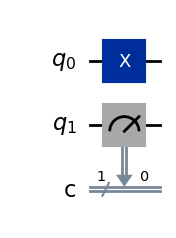

Noiseless: {'0': 1024}
Noisy: {'0': 1023, '1': 1}


In [4]:
case = 1

# -----------------------
# NOISELESS VERSION
# -----------------------

qc_ideal = QuantumCircuit(2, 1)

# Manually choose the input
qc_ideal.x(0)   # x = 1
# lack of qc_ideal.x(0) means x = 0

qc_ideal.compose(deutsch_function(case), inplace=True)

qc_ideal.measure(1, 0)

display(qc_ideal.draw("mpl"))

sampler_ideal = StatevectorSampler()
job_ideal = sampler_ideal.run([qc_ideal], shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal[0].data.c.get_counts()

print("Noiseless:", counts_ideal)


# -----------------------
# NOISY VERSION
# -----------------------

qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)


sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

# We obtain f(x) for a manually chosen input x.
# To determine if the function is constant or balanced,
# we must check both x = 0 and x = 1 separately. 

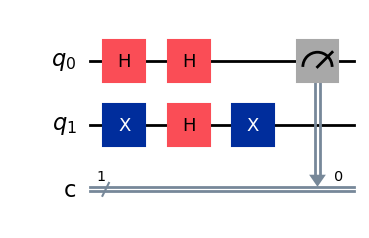

Noiseless: {'0': 1024}
Noiseless result: constant
Noisy: {'0': 1023, '1': 1}
Noisy result: constant


In [29]:
#EXCERCISE 1.3 - Deutch algorithm


case = 4
deutsch_func = deutsch_function(case)


# -----------------------
# NOISELESS VERSION
# -----------------------

qc_ideal = QuantumCircuit(2, 1)

qc_ideal.x(1)
qc_ideal.h(0)
qc_ideal.h(1)

qc_ideal.compose(deutsch_func, inplace=True)

qc_ideal.h(0)
qc_ideal.measure(0, 0)

display(qc_ideal.draw("mpl"))

sampler_ideal = StatevectorSampler()
job_ideal = sampler_ideal.run([qc_ideal], shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal[0].data.c.get_counts()

print("Noiseless:", counts_ideal)

if counts_ideal.get("0", 0) > counts_ideal.get("1", 0):
    print("Noiseless result: constant")
else:
    print("Noiseless result: balanced")


# -----------------------
# NOISY VERSION
# -----------------------

qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)


sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

if counts_noisy.get("0", 0) > counts_noisy.get("1", 0):
    print("Noisy result: constant")
else:
    print("Noisy result: balanced")

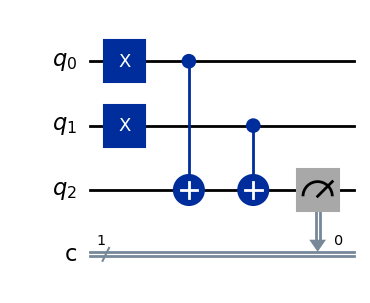

{'0': 1024}


In [ ]:
# DEUTSCH–JOZSA algorithm - EXERCISE 2
# Here we manually evaluate the function f(x0, x1) for a chosen input.
# This does NOT implement the Deutsch–Jozsa algorithm and does NOT determine
# whether the function is constant or balanced. Full classification would
# require checking all possible inputs (00, 01, 10, 11).

qc = QuantumCircuit(3, 1)  # we have 3 qubits: x0, x1 (inputs) and one output qubit

qc.x(0)  # manually set x0 = 1 
qc.x(1)  # manually set x1 = 1 

qc.cx(0, 2)
qc.cx(1, 2)

qc.measure(2, 0) 

display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)  

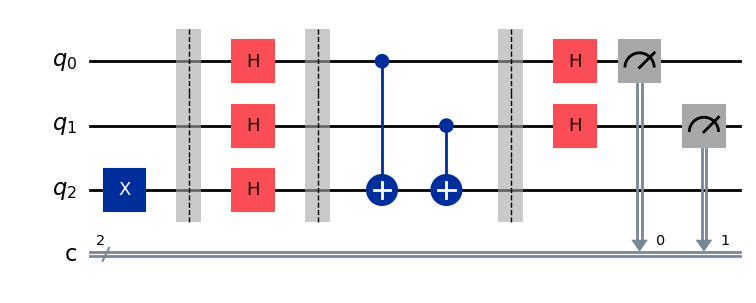

{'11': 1024}
balanced


In [ ]:
#Deutsh jozsa algorithm for 2-bit input - EXCERCISE 2.2
qc = QuantumCircuit(3, 2) 
qc.x(2)

qc.barrier()
qc.h(0)
qc.h(1)
qc.h(2)


qc.barrier()
qc.cx(0, 2)
qc.cx(1, 2)
qc.barrier()

qc.h(0)
qc.h(1)

qc.measure(0,0)
qc.measure(1,1)
display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)

if counts.get("0", 0) > counts.get("1", 0):
    print("constant")
else:
    print("balanced")


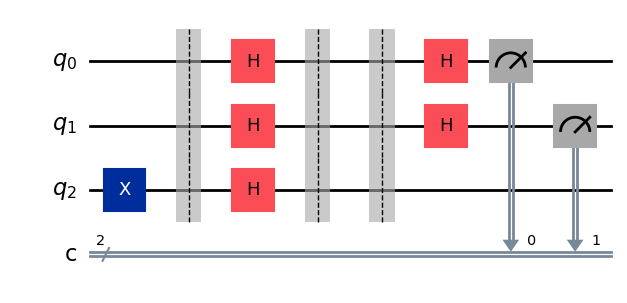

{'00': 1024}
constant


In [38]:
#Deutsh jozsa algorithm for 2-bit input - EXCERCISE 2.3 - all zeros
qc = QuantumCircuit(3, 2) 
qc.x(2)

qc.barrier()
qc.h(0)
qc.h(1)
qc.h(2)


qc.barrier()

qc.barrier()

qc.h(0)
qc.h(1)

qc.measure(0,0)
qc.measure(1,1)
display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)

if counts.get("00", 0) > 0:
    print("constant")
else:
    print("balanced")

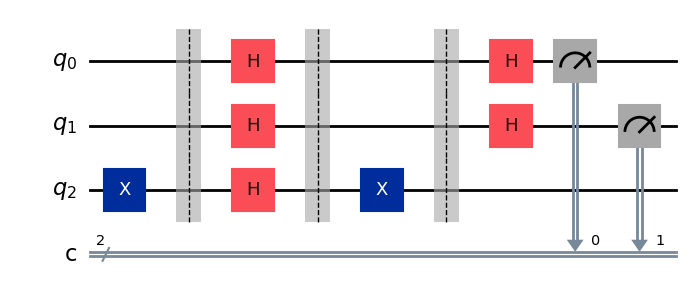

{'00': 1024}
constant


In [39]:
#Deutsh jozsa algorithm for 2-bit input - EXCERCISE 2.3 - all ones
qc = QuantumCircuit(3, 2) 
qc.x(2)

qc.barrier()
qc.h(0)
qc.h(1)
qc.h(2)


qc.barrier()
qc.x(2)
qc.barrier()

qc.h(0)
qc.h(1)

qc.measure(0,0)
qc.measure(1,1)
display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)

if counts.get("00", 0) > 0:
    print("constant")
else:
    print("balanced")

In [8]:
#EXCERCISE 2.4
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc


def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc



def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

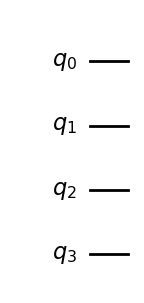

Noiseless: {'000': 1024}
Noisy: {'000': 1020, '010': 1, '100': 3}
Algorithm result: constant


In [ ]:
#EXCERCISE 2.4 and 2.5

from qiskit import transpile
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv

f = dj_query(3)
display(f.draw("mpl"))

qc = compile_circuit(f)

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()

print("Noiseless:", counts)

backend = FakeKyiv()
qc_noisy = transpile(qc, backend)

sampler_noisy = SamplerV2(backend)
result_noisy = sampler_noisy.run([qc_noisy], shots=1024).result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

print("Algorithm result:", dj_algorithm(f))